#  Effect of Target Variable Transformations on House Price Prediction

## Explore the Target Variable

In [51]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import boxcox

In [3]:
# import the dataset from scikit-learn Library
from sklearn.datasets import fetch_california_housing

In [108]:
# Assigning the House dataset variable
housing = fetch_california_housing()

In [109]:
df = pd.DataFrame(housing.data, columns = housing.feature_names)

In [117]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

In [118]:
X = df.drop(columns = "MedHouseVal")

In [119]:
X.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')

In [114]:
df['MedHouseVal'] = data.target
y = df["MedHouseVal"]

In [116]:
y.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

In [68]:
# Assigning the Target and feature variables


In [121]:
# check the shape of the Target and the Features
print(f"Features: {X.shape}")
print(f"Target: {y.shape}")

Features: (20640, 8)
Target: (20640,)


In [70]:
X = pd.DataFrame(X)
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [71]:
y.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

In [72]:
print(f"Skewness of the Target variabke-house prices {y.skew()}")

Skewness of the Target variabke-house prices 0.9777632739098335


> The skewness of MedHouseVal is positive, indicating that the distribution of house prices is right-skewed. This implies that while most homes are priced around the median range, there are fewer homes with extremely high values, which stretch the distribution’s tail to the right.

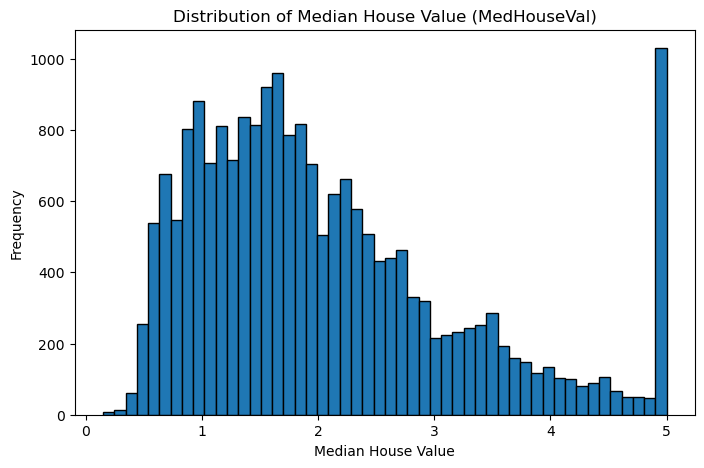

In [73]:
plt.figure(figsize=(8,5))
plt.hist(y, bins=50, edgecolor = 'black')
plt.title("Distribution of Median House Value (MedHouseVal)")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.show()


## Target Variable Transformation

### Logarithmic Transformation

In [74]:
y_log = np.log(y)

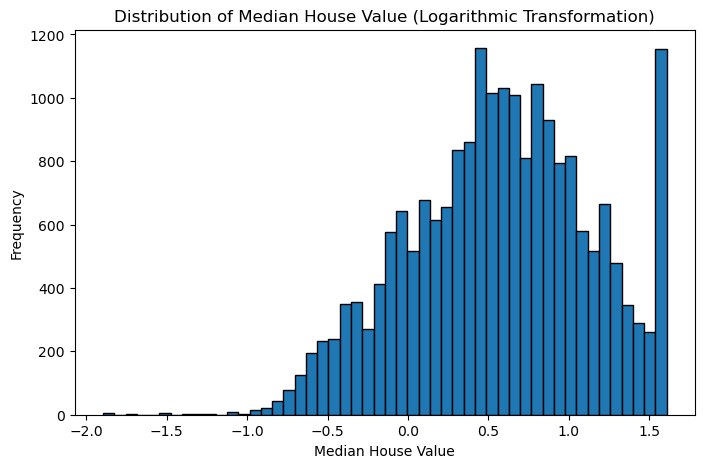

In [75]:
plt.figure(figsize=(8,5))
plt.hist(y_log, bins=50, edgecolor = 'black')
plt.title("Distribution of Median House Value (Logarithmic Transformation)")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.show()


> The Logarithmic Transformation makes the distribution become negatively skewed

### Square Root Transformation

In [76]:
y_sqrt = np.sqrt(y)

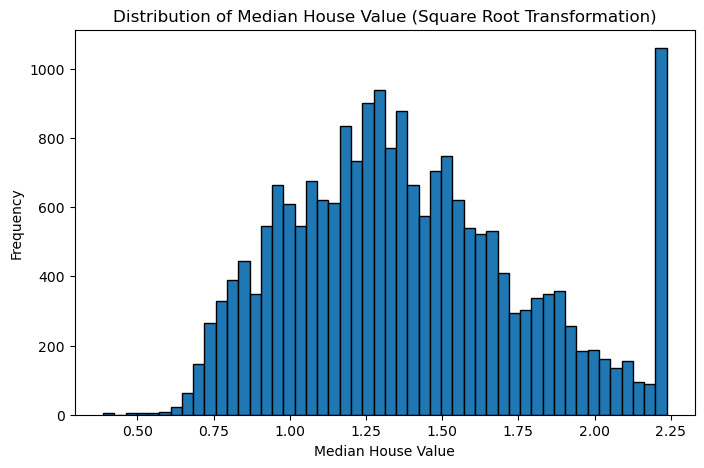

In [77]:
plt.figure(figsize=(8,5))
plt.hist(y_sqrt, bins=50, edgecolor = 'black')
plt.title("Distribution of Median House Value (Square Root Transformation)")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.show()

> The Square Root Transformation makes the Distribution Symmetric

### Box-Cox Transformation

In [79]:
y_bc, lam = boxcox(y)

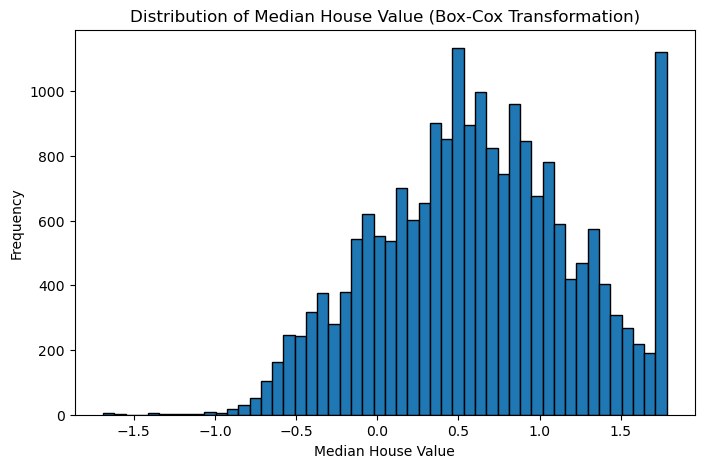

In [81]:
plt.figure(figsize=(8,5))
plt.hist(y_bc, bins=50, edgecolor = 'black')
plt.title("Distribution of Median House Value (Box-Cox Transformation)")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.show()

### Yeo-Johnson Transformation

In [82]:
from sklearn.preprocessing import PowerTransformer

In [85]:
pt = PowerTransformer(method = "yeo-johnson")
y_yj = pt.fit_transform(y.values.reshape(-1, 1))

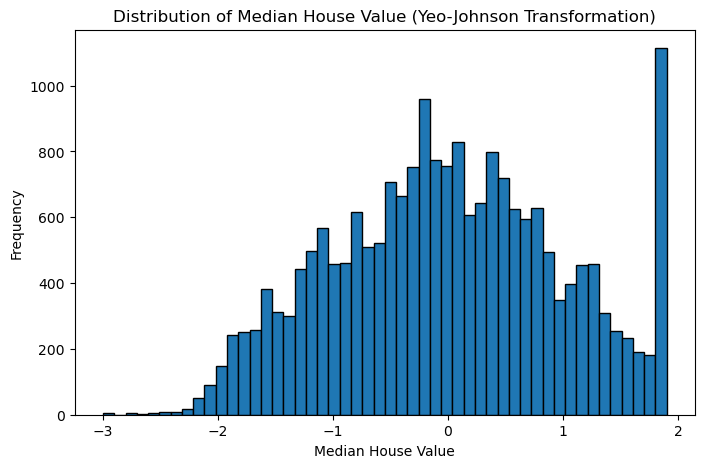

In [87]:
plt.figure(figsize=(8,5))
plt.hist(y_yj, bins=50, edgecolor = 'black')
plt.title("Distribution of Median House Value (Yeo-Johnson Transformation)")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.show()

### Quantile Transformation

In [89]:
from sklearn.preprocessing import QuantileTransformer

In [90]:
qt = QuantileTransformer(
    output_distribution = "normal",
    random_state = 42
)

In [91]:
y_qt = qt.fit_transform(y.values.reshape(-1, 1))

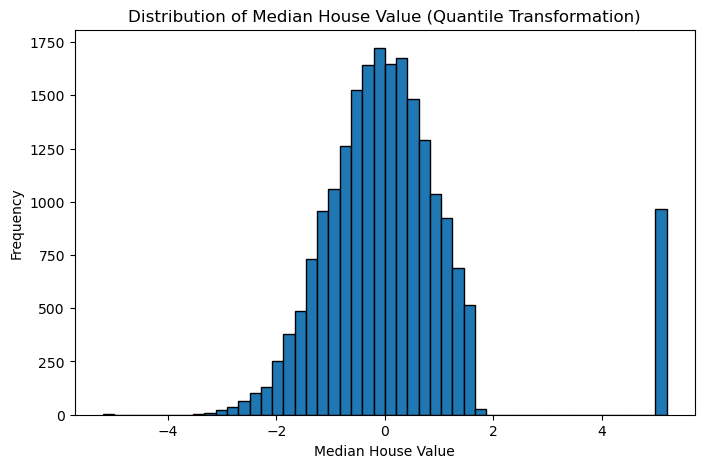

In [92]:
plt.figure(figsize=(8,5))
plt.hist(y_qt, bins=50, edgecolor = 'black')
plt.title("Distribution of Median House Value (Quantile Transformation)")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.show()

## Data Splitting

In [93]:
from sklearn.model_selection import train_test_split

In [124]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                   random_state = 42,
                                                   test_size = 0.2)

## Model Development

### Original Target

In [125]:
from sklearn.linear_model import LinearRegression

In [126]:
linear = LinearRegression()

In [129]:
linear.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### Predict the Target Variables

In [132]:
y_pred = linear.predict(X_test)
y_pred

array([0.71912284, 1.76401657, 2.70965883, ..., 4.46877017, 1.18751119,
       2.00940251], shape=(4128,))

#### Evaluate the model using MAE, MSE, RMSE

In [134]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error

In [139]:
mae = mean_absolute_error(y_pred, y_test)
mse = mean_squared_error(y_pred, y_test)
rmse = np.sqrt(mse)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMAE: {rmse:.4f}")

MAE: 0.5332
MSE: 0.5559
RMAE: 0.7456


### Log-Transformed Target

In [140]:
y_test_log = np.log(y_test)
y_train_log = np.log(y_train)

In [141]:
# fit the log-transformed Target
linear.fit(X_test, y_test_log)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### predict the Target variable

In [143]:
y_pred_log = linear.predict(X_test)
y_pred_log

array([-0.11760421,  0.48569792,  0.83570334, ...,  1.67846182,
        0.12158256,  0.55251193], shape=(4128,))

#### Evaluate the model using MAE, MSE, RMSE

In [165]:
mae_log = mean_absolute_error(y_pred_log, y_test_log)
mse_log = mean_squared_error(y_pred_log, y_test_log)
rmse_log = np.sqrt(mse_log)

print(f"LOG TRANSFORMED MAE: {mae_log:.4f}")
print(f"LOG TRANSFORMED MSE: {mse_log:.4f}")
print(f"LOG TRANSFORMED RMAE: {rmse_log:.4f}")

LOG TRANSFORMED MAE: 0.2671
LOG TRANSFORMED MSE: 0.1273
LOG TRANSFORMED RMAE: 0.3568


### Square Root-Transformed Target

In [146]:
y_test_sqrt = np.sqrt(y_test)
y_train_sqrt = np.sqrt(y_train)

In [147]:
# fit the square root-transformed target into the linear model
linear.fit(X_train, y_train_sqrt)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### Make Predictions

In [148]:
y_pred_sqrt = linear.predict(X_test)
y_pred_sqrt

array([0.91983284, 1.29815832, 1.58758422, ..., 2.185441  , 1.06748979,
       1.37771236], shape=(4128,))

#### Evaluate the Model

In [164]:
mae_sqrt = mean_absolute_error(y_pred_sqrt, y_test_sqrt)
mse_sqrt = mean_squared_error(y_pred_sqrt, y_test_sqrt)
rmse_sqrt = np.sqrt(mse_sqrt)

print(f"SQUARE ROOT TRANSFORMED MAE: {mae_sqrt:.4f}")
print(f"SQUARE ROOT TRANSFORMED MSE: {mse_sqrt:.4f}")
print(f"SQUARE ROOT TRANSFORMED RMAE: {rmse_sqrt:.4f}")

SQUARE ROOT TRANSFORMED MAE: 0.1812
SQUARE ROOT TRANSFORMED MSE: 0.0599
SQUARE ROOT TRANSFORMED RMAE: 0.2448


### Box-Cox -Transformed Target

In [151]:
y_test_bc, lam = boxcox(y_test)
y_train_bc, lam = boxcox(y_train)

In [152]:
# fit the Box-Cox Transformed Y into the linear Regression
linear.fit(X_train, y_train_bc)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### Make Predictions

In [153]:
y_pred_bc = linear.predict(X_test)
y_pred_bc

array([-0.11812563,  0.49854323,  0.90825496, ...,  1.83946204,
        0.09713427,  0.61834923], shape=(4128,))

#### Evaluate the Model

In [163]:
mae_bc = mean_absolute_error(y_pred_bc, y_test_bc)
mse_bc = mean_squared_error(y_pred_bc, y_test_bc)
rmse_bc = np.sqrt(mse_bc)

print(f"SQUARE ROOT TRANSFORMED MAE: {mae_bc:.4f}")
print(f"SQUARE ROOT TRANSFORMED MSE: {mse_bc:.4f}")
print(f"SQUARE ROOT TRANSFORMED RMAE: {rmse_bc:.4f}")

SQUARE ROOT TRANSFORMED MAE: 0.2903
SQUARE ROOT TRANSFORMED MSE: 0.1510
SQUARE ROOT TRANSFORMED RMAE: 0.3886


### Yeo-Johnson Transformation

In [170]:
y_test_yj = pt.fit_transform(y_test.values.reshape(-1, 1))
y_train_yj = pt.fit_transform(y_train.values.reshape(-1, 1))

In [171]:
# fit the Yeo-Johnson Transformed Y
linear.fit(X_train, y_train_yj.ravel())

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### Make Predictions

In [172]:
y_pred_yj = linear.predict(X_train)
y_pred_yj

array([-0.02632839,  0.33324928,  0.80549545, ...,  0.00691702,
        0.70801681,  0.16900707], shape=(16512,))

#### Evaluate the Model

In [177]:
mae_yj = mean_absolute_error( y_test_yj, y_pred_yj)
mse_yj = mean_squared_error(y_pred_yj, y_test_yj)
rmse_yj = np.sqrt(mse)

print(f"SQUARE ROOT TRANSFORMED MAE: {mae_yj:.4f}")
print(f"SQUARE ROOT TRANSFORMED MSE: {mse_yj:.4f}")
print(f"SQUARE ROOT TRANSFORMED RMAE: {rmse_yj:.4f}")

SQUARE ROOT TRANSFORMED MAE: 0.4756
SQUARE ROOT TRANSFORMED MSE: 0.3998
SQUARE ROOT TRANSFORMED RMAE: 0.7456


### Quantile -Transformed Target

In [179]:
y_test_qt = qt.fit_transform(y_test.values.reshape(-1, 1))
y_train_qt = qt.fit_transform(y_train.values.reshape(-1, 1))

In [180]:
# fit the Quantile Transformed into the Linear Regression
linear.fit(X_train, y_train_qt.ravel())

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### Make Predictions

In [181]:
y_pred_qt = linear.predict(X_test)
y_pred_qt

array([-1.46505849, -0.26579168,  0.92406268, ...,  3.05213374,
       -0.91041976,  0.09133426], shape=(4128,))

#### Evaluate the Model

In [182]:
mae_qt = mean_absolute_error( y_test_qt, y_pred_qt)
mse_qt = mean_squared_error(y_pred_qt, y_test_qt)
rmse_qt = np.sqrt(mse_qt)

print(f"SQUARE ROOT TRANSFORMED MAE: {mae_qt:.4f}")
print(f"SQUARE ROOT TRANSFORMED MSE: {mse_qt:.4f}")
print(f"SQUARE ROOT TRANSFORMED RMAE: {rmse_qt:.4f}")

SQUARE ROOT TRANSFORMED MAE: 0.5971
SQUARE ROOT TRANSFORMED MSE: 0.9131
SQUARE ROOT TRANSFORMED RMAE: 0.9556


## Performance Comparison

In [192]:
mae = round(mae, 4)
mse = round(mse, 4)
rmse = round(rmse, 4)

mae_log = round(mae_log, 4)
mse_log = round(mse_log, 4)
rmse = round(rmse_log, 4)

mae_sqrt = round(mae_sqrt, 4)
mse_sqrt = round(mse_sqrt, 4)
rmse_sqrt = round(rmse_sqrt, 4)

mae_bc = round(mae_bc, 4)
mse_bc = round(mse_bc, 4)
rmse_bc = round(rmse_bc, 4)

mae_yj = round(mae_yj, 4)
mse_yj = round(mse_yj, 4)
rmse_yj = round(rmse_yj, 4)

mae_qt = round(mae_qt, 4)
mse_qt = round(mse_qt, 4)
rmse_qt = round(rmse_qt, 4)



In [194]:
perf_table = pd.DataFrame({
    "Target Variable" : ["Original", "Logarithm", "Square Root", "Box-Cox", "Yeo-Johnson", "Quantile"],
    "MAE" : [mae, mae_log, mae_sqrt, mae_bc, mae_yj, mae_qt],
    "MSE" : [mse, mse_log, mse_sqrt, mae_bc, mse_yj, mse_qt],
    "RMSE" : [rmse, rmse_log, rmse_sqrt, rmse_bc, rmse_yj, rmse_qt]
})

In [195]:
perf_table

,Target Variable,MAE,MSE,RMSE
0,Original,0.5332,0.5559,0.356800
1,Logarithm,0.2671,0.1273,0.356757
2,Square Root,0.1812,0.0599,0.244800
3,Box-Cox,0.2903,0.2903,0.388600
4,Yeo-Johnson,0.4756,0.3998,0.745600
5,Quantile,0.5971,0.9131,0.955600
